In [1]:
# ── 1. Load env ───────────────────────────────────────────────
import os
from dotenv import load_dotenv

load_dotenv()

def get_env(key: str) -> str:
    value = os.getenv(key)
    if not value:
        raise ValueError(f"Missing required environment variable: {key}")
    return value

OPENAI_API_KEY = get_env("OPENAI_API_KEY")
MODEL_NAME     = get_env("MODEL_NAME")

print("✅ Env loaded")


✅ Env loaded


In [2]:
# ── 2. Detect OS ──────────────────────────────────────────────
import platform

OS_TYPE = platform.system()   # 'Darwin' | 'Windows' | 'Linux'
print(f"Detected OS: {OS_TYPE}")

Detected OS: Darwin


In [3]:
# ── 3. Shell tool ─────────────────────────────────────────────
import subprocess
from langchain_core.tools import tool

@tool
def run_shell_command(command: str) -> str:
    """
    Runs a shell command on the host machine.
    Use zsh commands on Mac/Linux, PowerShell commands on Windows.
    Returns the output or error as a string.
    """
    try:
        if OS_TYPE == "Windows":
            result = subprocess.run(
                ["powershell", "-Command", command],
                capture_output=True, text=True, timeout=30
            )
        else:
            result = subprocess.run(
                ["zsh", "-c", command],
                capture_output=True, text=True, timeout=30
            )

        if result.returncode != 0:
            return f"Error: {result.stderr.strip()}"
        return result.stdout.strip() or "Command executed successfully with no output."

    except subprocess.TimeoutExpired:
        return "Error: Command timed out after 30 seconds."
    except Exception as e:
        return f"Error: {str(e)}"

print("✅ Shell tool ready")

✅ Shell tool ready


In [4]:
# ── 4. LLM + bind tool ────────────────────────────────────────
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model=MODEL_NAME,
    api_key=OPENAI_API_KEY,
)

tools = [run_shell_command]
llm_with_tools = llm.bind_tools(tools)

print("✅ LLM ready")

✅ LLM ready


In [5]:
# ── 5. Graph state ────────────────────────────────────────────
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

print("✅ State defined")

✅ State defined


In [6]:
# ── 6. Nodes ──────────────────────────────────────────────────
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode

SYSTEM_PROMPT = f"""You are a helpful OS assistant running on {OS_TYPE}.
You can run shell commands to help the user with system operations.
{'Use zsh commands.' if OS_TYPE != 'Windows' else 'Use PowerShell commands.'}
Always explain what you are doing before running a command."""

def agent_node(state: AgentState) -> AgentState:
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

print("✅ Nodes ready")

✅ Nodes ready


In [7]:
# ── 7. Conditional edge ───────────────────────────────────────
from langchain_core.messages import AIMessage

def should_continue(state: AgentState) -> str:
    last_message = state["messages"][-1]
    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "tool"     # → run tool
    return "end"          # → finish

print("✅ Conditional edge ready")

✅ Conditional edge ready


In [8]:
# ── 8. Build graph ────────────────────────────────────────────
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(AgentState)

graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tool",  tool_node)

graph_builder.add_edge(START, "agent")

graph_builder.add_conditional_edges(
    "agent",
    should_continue,
    {"tool": "tool", "end": END}
)

graph_builder.add_edge("tool", "agent")   # loop back

graph = graph_builder.compile()

print("✅ Graph compiled")

✅ Graph compiled


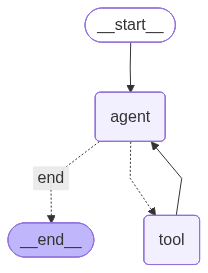

In [9]:
# ── 9. Visualise graph (optional) ─────────────────────────────
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("(Install pygraphviz / playwright to render graph image)")

In [10]:
# ── 10. Run agent ─────────────────────────────────────────────
from langchain_core.messages import HumanMessage

def chat(user_input: str):
    print(f"\nUser: {user_input}")
    print("-" * 50)
    result = graph.invoke({"messages": [HumanMessage(content=user_input)]})
    final  = result["messages"][-1].content
    print(f"Agent: {final}")
    return final

# Test it
chat("What are the specifications of this machine?")


User: What are the specifications of this machine?
--------------------------------------------------
Agent: Here are the specifications of your machine:

### CPU Information
- **Processor**: Apple M4

### Memory Information
- **Total Memory**: 16 GB (17179869184 bytes)

### Disk Usage
Here's a summary of the disk usage for your volumes:

- **/ (Root)**: 228 GB total, 12 GB used, 103 GB available (11% used)
- **/System/Volumes/VM**: 228 GB total, 20 KB used, 103 GB available (1% used)
- **/System/Volumes/Preboot**: 228 GB total, 8.4 GB used, 103 GB available (8% used)
- **/System/Volumes/Update**: 228 GB total, 6.7 MB used, 103 GB available (1% used)
- **/System/Volumes/xarts**: 500 MB total, 6 MB used, 483 MB available (2% used)
- **/System/Volumes/iSCPreboot**: 500 MB total, 6 MB used, 483 MB available (2% used)
- **/System/Volumes/Hardware**: 500 MB total, 712 KB used, 483 MB available (1% used)
- **/System/Volumes/Data**: 228 GB total, 104 GB used, 103 GB available (51% used)

###

"Here are the specifications of your machine:\n\n### CPU Information\n- **Processor**: Apple M4\n\n### Memory Information\n- **Total Memory**: 16 GB (17179869184 bytes)\n\n### Disk Usage\nHere's a summary of the disk usage for your volumes:\n\n- **/ (Root)**: 228 GB total, 12 GB used, 103 GB available (11% used)\n- **/System/Volumes/VM**: 228 GB total, 20 KB used, 103 GB available (1% used)\n- **/System/Volumes/Preboot**: 228 GB total, 8.4 GB used, 103 GB available (8% used)\n- **/System/Volumes/Update**: 228 GB total, 6.7 MB used, 103 GB available (1% used)\n- **/System/Volumes/xarts**: 500 MB total, 6 MB used, 483 MB available (2% used)\n- **/System/Volumes/iSCPreboot**: 500 MB total, 6 MB used, 483 MB available (2% used)\n- **/System/Volumes/Hardware**: 500 MB total, 712 KB used, 483 MB available (1% used)\n- **/System/Volumes/Data**: 228 GB total, 104 GB used, 103 GB available (51% used)\n\n### Operating System Version\n- **macOS Version**: 26.5\n- **Build Version**: 25F71\n\nThese

In [ ]:
# ── 11. More test cases ───────────────────────────────────────
chat("Create a folder called test_agent on the Desktop")
chat("What is the current date and time?")